# 🚀 GNN Fraud Detection v2 - Google Colab (Improved)

## Cải tiến so với v1:
- ✅ **40+ features** thay vì chỉ 6 (thêm C1-C14, D1-D15, V12-V40)
- ✅ **Learnable entity embeddings** thay vì zero vectors
- ✅ **Stronger class imbalance handling**: tăng alpha Focal Loss + class weights
- ✅ **Optimized hyperparameters** cho từng architecture

**Hướng dẫn:**
1. **Runtime → Change runtime type → GPU T4**
2. Upload `train_transaction.csv` + `train_identity.csv`
3. Run all cells

In [1]:
!pip install torch-geometric polars -q
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__.split("+")[0])')+cu$(python -c 'import torch; print(torch.version.cuda.replace(".",""))').html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 69.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 145.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 124.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 80.4 MB/s eta 0:00:00


In [2]:
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE'}")
assert torch.cuda.is_available(), "GPU not available! Go to Runtime > Change runtime type > GPU"

PyTorch: 2.10.0+cu128, CUDA: 12.8
GPU: Tesla T4


## 1. Upload Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
from pathlib import Path

DATA_DIR = Path('/content/drive/MyDrive/ieee/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/ieee/output')
MODEL_DIR = Path('/content/drive/MyDrive/ieee/models')
for d in [DATA_DIR, OUTPUT_DIR/'metrics', MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

tran_path = DATA_DIR / 'train_transaction.csv'
iden_path = DATA_DIR / 'train_identity.csv'

if not tran_path.exists() or not iden_path.exists():
    from google.colab import files
    print("Upload train_transaction.csv and train_identity.csv")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(DATA_DIR / name, 'wb') as f: f.write(content)
    print("Upload complete!")
else:
    print(f"Data exists: {list(DATA_DIR.glob('*.csv'))}")

Data exists: [PosixPath('/content/drive/MyDrive/ieee/data/train_identity.csv'), PosixPath('/content/drive/MyDrive/ieee/data/train_transaction.csv')]


### 1b. (Thay thế) Mount Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/drive/MyDrive/data/train_transaction.csv /content/data/
# !cp /content/drive/MyDrive/data/train_identity.csv /content/data/

## 2. Config & Imports

In [5]:
import random, time, functools, gc
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.data import HeteroData
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import HeteroConv, SAGEConv, GATConv, GraphConv, BatchNorm
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

# ==================== CONFIG ====================
SEED = 42
DEVICE = torch.device('cuda')

# === EXPANDED COLUMNS (v2) ===
C_COLS = [f'C{i}' for i in range(1, 15)]  # C1-C14
D_COLS = [f'D{i}' for i in range(1, 16)]  # D1-D15
V_COLS = [f'V{i}' for i in range(12, 40)]  # V12-V39 (less missing)

USECOLS_TRANSACTION = [
    'TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
    'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain',
] + C_COLS + D_COLS + V_COLS

USECOLS_IDENTITY = [
    'TransactionID', 'DeviceType', 'DeviceInfo', 'id_30', 'id_31',
]

ENTITY_SCHEMA = [
    ('card1', 'card1'), ('card2', 'card2'), ('card3', 'card3'),
    ('card4', 'card4'), ('card5', 'card5'), ('card6', 'card6'),
    ('addr1', 'addr1'), ('addr2', 'addr2'),
    ('P_emaildomain', 'P_email'), ('R_emaildomain', 'R_email'),
    ('ProductCD', 'product'),
    ('DeviceType', 'device_type'), ('DeviceInfo', 'device_info'),
    ('id_30', 'os'), ('id_31', 'browser'),
]

MIN_FREQ = 2
KEEP_TOP_K = 5000
ADD_REVERSE_EDGES = True
TXN_TXN_SHARED_KEY = 'card1'
TXN_TXN_MAX_DEGREE = 5

TRAIN_RATIO = 0.70
VAL_RATIO = 0.10

# GNN Hyperparameters
HIDDEN_DIM = 128
NUM_LAYERS = 2
NUM_HEADS = 4
DROPOUT = 0.3
NUM_EPOCHS = 50
PATIENCE = 10
BATCH_SIZE = 1024
NUM_NEIGHBORS = [15, 10]

# Per-model LR (GAT needs lower LR)
MODEL_LR = {
    'HeteroSAGE': 5e-4,
    'HeteroGAT': 3e-4,
    'HeteroRGCN': 5e-4,
}
WEIGHT_DECAY = 5e-5

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed()
print(f'Device: {DEVICE}')
print(f'Transaction features: {len(C_COLS)} C + {len(D_COLS)} D + {len(V_COLS)} V + 6 engineered = {len(C_COLS)+len(D_COLS)+len(V_COLS)+6}')

Device: cuda
Transaction features: 14 C + 15 D + 28 V + 6 engineered = 63


## 3. Utilities

In [6]:
def timer(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        print(f'[{func.__name__}] {time.time()-t0:.2f}s')
        return result
    return wrapper

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        return (alpha_t * (1 - pt) ** self.gamma * ce).mean()

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience, self.counter, self.best = patience, 0, -1.0
    def __call__(self, score):
        if score > self.best:
            self.best, self.counter = score, 0
        else:
            self.counter += 1
        return self.counter >= self.patience

print('Utilities loaded.')

Utilities loaded.


## 4. Load Data

In [7]:
@timer
def load_data():
    lt = pl.scan_csv(str(DATA_DIR/'train_transaction.csv'), infer_schema_length=5000)
    # Only select columns that exist
    avail_cols = lt.collect_schema().names()
    use_tran = [c for c in USECOLS_TRANSACTION if c in avail_cols]
    lt = lt.select(use_tran)

    li = pl.scan_csv(str(DATA_DIR/'train_identity.csv'), infer_schema_length=5000).select(USECOLS_IDENTITY)
    df = lt.join(li, on='TransactionID', how='left').collect(streaming=False)
    df = df.with_row_index(name='txn_index')

    n = df.height
    fr = int(df['isFraud'].sum())
    print(f'Loaded {n:,} txns, fraud: {fr:,} ({fr/n*100:.2f}%)')
    print(f'Columns used: {len(use_tran)} from transaction + {len(USECOLS_IDENTITY)-1} from identity')
    return df, use_tran

df, used_tran_cols = load_data()

/tmp/ipykernel_764/3043120360.py:10: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  df = lt.join(li, on='TransactionID', how='left').collect(streaming=False)


Loaded 590,540 txns, fraud: 20,663 (3.50%)
Columns used: 72 from transaction + 4 from identity
[load_data] 18.53s


## 5. Feature Engineering (v2 - 40+ features)

In [8]:
@timer
def build_features_v2(df, used_cols):
    features = []

    # === Amount features (2) ===
    amt = df['TransactionAmt'].cast(pl.Float64).fill_null(0.0).to_numpy()
    mu, sd = float(np.mean(amt)), max(float(np.std(amt)), 1.0)
    features.append((amt - mu) / (sd + 1e-6))
    features.append(np.log1p(amt))

    # === Time features (4) ===
    sec = df['TransactionDT'].cast(pl.Float64).fill_null(0.0).to_numpy()
    hour = (sec % 86400.0) / 3600.0
    dow = ((sec // 86400.0) % 7.0)
    features.append(np.sin(2*np.pi*hour/24))
    features.append(np.cos(2*np.pi*hour/24))
    features.append(np.sin(2*np.pi*dow/7))
    features.append(np.cos(2*np.pi*dow/7))

    # === C columns (counting features) ===
    for col in C_COLS:
        if col in used_cols:
            arr = df[col].cast(pl.Float64).fill_null(0.0).to_numpy()
            features.append(np.log1p(arr))

    # === D columns (timedelta features) ===
    for col in D_COLS:
        if col in used_cols:
            arr = df[col].cast(pl.Float64).fill_null(-1.0).to_numpy()
            features.append(arr)

    # === V columns (Vesta-engineered features) ===
    for col in V_COLS:
        if col in used_cols:
            arr = df[col].cast(pl.Float64).fill_null(0.0).to_numpy()
            features.append(arr)

    X = np.ascontiguousarray(np.stack(features, axis=1).astype(np.float32))

    # Robust normalization (clip outliers)
    for i in range(X.shape[1]):
        col = X[:, i]
        p1, p99 = np.percentile(col, 1), np.percentile(col, 99)
        col = np.clip(col, p1, p99)
        med = np.median(col)
        iqr = np.percentile(col, 75) - np.percentile(col, 25)
        if iqr > 1e-6:
            X[:, i] = (col - med) / iqr
        else:
            X[:, i] = col - med

    y = df.select(pl.col('isFraud').fill_null(0).cast(pl.Int64))['isFraud'].to_numpy()
    print(f'Features: {X.shape} ({X.shape[1]} dims), Fraud: {y.sum():,}/{len(y):,}')
    return X, y

X, y = build_features_v2(df, used_tran_cols)

Features: (590540, 63) (63 dims), Fraud: 20,663/590,540
[build_features_v2] 4.24s


## 6. Build Heterogeneous Graph

In [9]:
@timer
def build_graph(df, X, y):
    data = HeteroData()
    num_txn = df.height

    data['txn'].num_nodes = num_txn
    data['txn'].x = torch.from_numpy(X).contiguous()
    data['txn'].y = torch.tensor(y, dtype=torch.long).contiguous()

    # === Entity indexers ===
    idx_map = {}
    for col, etype in ENTITY_SCHEMA:
        if col not in df.columns:
            print(f'  SKIP {etype} (column {col} not found)')
            continue
        vc = (
            df.select(pl.col(col).cast(pl.Utf8).alias(col))
            .with_columns(pl.col(col).fill_null(''))
            .group_by(col).len().rename({'len': 'cnt'})
            .filter(pl.col(col) != '')
            .sort('cnt', descending=True)
        )
        if KEEP_TOP_K: vc = vc.head(KEEP_TOP_K)
        if MIN_FREQ > 1: vc = vc.filter(pl.col('cnt') >= MIN_FREQ)
        vc = vc.with_row_index(name='eid').select([col, 'eid'])
        idx_map[etype] = dict(zip(vc[col].to_list(), vc['eid'].to_list()))
        print(f'  {etype}: {len(idx_map[etype]):,} unique values')

    # === Entity nodes with LEARNABLE embeddings (no dummy zeros) ===
    # We create a 1-hot index feature so the embedding layer can learn
    for _, etype in ENTITY_SCHEMA:
        if etype not in idx_map:
            continue
        n = len(idx_map[etype])
        data[etype].num_nodes = n
        # Use node index as feature → model's LazyLinear learns embedding
        data[etype].x = torch.arange(n, dtype=torch.float32).unsqueeze(1)

    # === Build edges ===
    for col, etype in ENTITY_SCHEMA:
        if etype not in idx_map: continue
        mapping = idx_map[etype]
        if not mapping: continue

        map_df = pl.DataFrame({col: list(mapping.keys()), 'eid': list(mapping.values())})
        edges_df = (
            df.select(['txn_index', pl.col(col).cast(pl.Utf8).fill_null('').alias(col)])
            .join(map_df, on=col, how='inner')
        )
        if edges_df.height == 0: continue

        src = torch.tensor(edges_df['txn_index'].to_numpy(), dtype=torch.long)
        dst = torch.tensor(edges_df['eid'].to_numpy(), dtype=torch.long)
        ei = torch.stack([src, dst], dim=0).contiguous()

        data[('txn', f'has_{etype}', etype)].edge_index = ei
        if ADD_REVERSE_EDGES:
            data[(etype, f'rev_{etype}', 'txn')].edge_index = torch.stack([dst, src], dim=0).contiguous()
        print(f'  txn->{etype}: {ei.shape[1]:,} edges')

    # === Txn-txn edges ===
    print(f'Building txn-txn edges on {TXN_TXN_SHARED_KEY}...')
    groups = df.select(['txn_index', pl.col(TXN_TXN_SHARED_KEY).cast(pl.Utf8).fill_null('').alias(TXN_TXN_SHARED_KEY)]).to_pandas()
    by = {}
    for idx, val in zip(groups['txn_index'].values, groups[TXN_TXN_SHARED_KEY].values):
        if val: by.setdefault(val, []).append(int(idx))
    rows, cols = [], []
    for val, idxs in by.items():
        if len(idxs) < 2: continue
        L = len(idxs)
        for i in range(L):
            for j in range(max(0, i-TXN_TXN_MAX_DEGREE), min(L, i+TXN_TXN_MAX_DEGREE+1)):
                if j != i: rows.append(idxs[i]); cols.append(idxs[j])
    if rows:
        ei = torch.unique(torch.tensor([rows, cols], dtype=torch.long), dim=1).contiguous()
        data[('txn', 'same_card', 'txn')].edge_index = ei
        print(f'  txn->txn: {ei.shape[1]:,} edges')

    # === Time-based masks ===
    time_col = df['TransactionDT'].cast(pl.Float64)
    t1, t2 = float(time_col.quantile(TRAIN_RATIO)), float(time_col.quantile(TRAIN_RATIO + VAL_RATIO))
    times = time_col.fill_null(t1).to_numpy()
    data['txn'].train_mask = torch.from_numpy(times <= t1).bool()
    data['txn'].val_mask = torch.from_numpy((times > t1) & (times <= t2)).bool()
    data['txn'].test_mask = torch.from_numpy(times > t2).bool()

    # Print fraud stats per split
    for sp in ['train', 'val', 'test']:
        m = getattr(data['txn'], f'{sp}_mask')
        fr = data['txn'].y[m].sum().item()
        print(f'  {sp}: {m.sum():,} nodes, {fr:,} fraud ({fr/m.sum()*100:.2f}%)')

    data = data.to(DEVICE)
    print(f'\nGraph on {DEVICE}: {len(data.node_types)} node types, {len(data.edge_types)} edge types')
    return data

data = build_graph(df, X, y)
del df, X, y; gc.collect(); torch.cuda.empty_cache()

  card1: 5,000 unique values
  card2: 500 unique values
  card3: 98 unique values
  card4: 4 unique values
  card5: 102 unique values
  card6: 4 unique values
  addr1: 209 unique values
  addr2: 56 unique values
  P_email: 59 unique values
  R_email: 60 unique values
  product: 5 unique values
  device_type: 2 unique values
  device_info: 1,346 unique values
  os: 74 unique values
  browser: 115 unique values
  txn->card1: 568,367 edges
  txn->card2: 581,607 edges
  txn->card3: 588,959 edges
  txn->card4: 588,963 edges
  txn->card5: 586,264 edges
  txn->card6: 588,969 edges
  txn->addr1: 524,711 edges
  txn->addr2: 524,816 edges
  txn->P_email: 496,084 edges
  txn->R_email: 137,291 edges
  txn->product: 590,540 edges
  txn->device_type: 140,810 edges
  txn->device_info: 118,226 edges
  txn->os: 77,564 edges
  txn->browser: 140,267 edges
Building txn-txn edges on card1...
  txn->txn: 5,596,200 edges
  train: 413,378 nodes, 14,538 fraud (3.52%)
  val: 59,054 nodes, 2,061 fraud (3.49%)
  

## 7. Data Loaders & Loss

In [10]:
loaders = {}
for split in ['train', 'val', 'test']:
    mask = getattr(data['txn'], f'{split}_mask')
    loaders[split] = NeighborLoader(
        data, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
        input_nodes=('txn', mask), shuffle=(split=='train'),
    )
    print(f'{split}: {mask.sum():,} nodes')

# Strong focal loss for imbalance (alpha=0.85 gives more weight to fraud)
loss_fn = FocalLoss(alpha=0.85, gamma=2.0)
print(f'Loss: FocalLoss(alpha=0.85, gamma=2.0)')

train: 413,378 nodes
val: 59,054 nodes
test: 118,108 nodes
Loss: FocalLoss(alpha=0.85, gamma=2.0)


## 8. GNN Model (v2 - with Entity Embeddings)

In [11]:
class HeteroGNN_v2(nn.Module):
    """
    Improved Heterogeneous GNN with:
    - Proper learnable entity embeddings
    - Feature extraction MLP before GNN
    - Supports sage/gat/rgcn
    """
    def __init__(self, metadata, in_channels, hidden=128, num_layers=2,
                 num_classes=2, dropout=0.3, conv_type='sage', num_heads=4,
                 entity_node_counts=None):
        super().__init__()
        self.dropout = dropout
        self.conv_type = conv_type
        node_types, edge_types = metadata

        # Feature extraction MLP for txn nodes
        self.feat_mlp = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
        )

        # Learnable entity embeddings (much better than zeros!)
        self.entity_embeds = nn.ModuleDict()
        if entity_node_counts:
            for ntype in node_types:
                if ntype != 'txn' and ntype in entity_node_counts:
                    n_entities = entity_node_counts[ntype]
                    self.entity_embeds[ntype] = nn.Embedding(n_entities, hidden)
                    nn.init.xavier_uniform_(self.entity_embeds[ntype].weight)
        else:
            for ntype in node_types:
                if ntype != 'txn':
                    self.entity_embeds[ntype] = nn.LazyLinear(hidden)

        # GNN layers
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            conv_dict = {}
            for et in edge_types:
                if conv_type == 'sage':
                    conv_dict[et] = SAGEConv((-1, -1), hidden)
                elif conv_type == 'gat':
                    hd = hidden // num_heads
                    conv_dict[et] = GATConv((-1,-1), hd, heads=num_heads,
                                           concat=True, dropout=dropout, add_self_loops=False)
                elif conv_type == 'rgcn':
                    conv_dict[et] = GraphConv((-1, -1), hidden)
            self.convs.append(HeteroConv(conv_dict, aggr='mean'))
            self.norms.append(BatchNorm(hidden))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x_dict, edge_index_dict):
        h_dict = {}
        for ntype, x in x_dict.items():
            if ntype == 'txn':
                h_dict[ntype] = self.feat_mlp(x)
            elif ntype in self.entity_embeds:
                embed = self.entity_embeds[ntype]
                if isinstance(embed, nn.Embedding):
                    # Use node indices for embedding lookup
                    idx = x.squeeze(-1).long().clamp(0, embed.num_embeddings - 1)
                    h_dict[ntype] = embed(idx)
                else:
                    h_dict[ntype] = embed(x)
            else:
                h_dict[ntype] = torch.zeros(x.shape[0], self.feat_mlp[0].out_features, device=x.device)

        act = F.elu if self.conv_type == 'gat' else F.relu

        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h_dict, edge_index_dict)
            out = {}
            for nt in h_new:
                h = h_new[nt]
                if h is None: continue
                if h.dim() == 2 and h.shape[0] > 0:
                    h = norm(h)
                    h = act(h)
                    h = F.dropout(h, p=self.dropout, training=self.training)
                    if nt in h_dict and h_dict[nt].shape == h.shape:
                        h = h + h_dict[nt]  # residual
                out[nt] = h
            for nt in h_dict:
                if nt not in out: out[nt] = h_dict[nt]
            h_dict = out

        return self.classifier(h_dict['txn'])

print('HeteroGNN_v2 defined.')

HeteroGNN_v2 defined.


## 9. Training Function

In [12]:
def train_model(model, loaders, loss_fn, name, lr=5e-4, epochs=NUM_EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    es = EarlyStopping(patience)
    best_state, best_f1 = None, 0.0
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[], 'val_auc':[]}

    print(f"\n{'='*60}\n{name} | LR={lr} | Device={DEVICE}\n{'='*60}")

    for epoch in range(1, epochs+1):
        t0 = time.time()

        # TRAIN
        model.train()
        tloss, tp, tl, nb = 0, [], [], 0
        for batch in loaders['train']:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            xd = {nt: batch[nt].x for nt in batch.node_types if hasattr(batch[nt],'x') and batch[nt].x is not None}
            ed = {et: batch[et].edge_index for et in batch.edge_types if hasattr(batch[et],'edge_index')}
            out = model(xd, ed)
            m = batch['txn'].train_mask if hasattr(batch['txn'],'train_mask') else torch.ones(out.shape[0], dtype=torch.bool, device=DEVICE)
            if m.sum()==0: continue
            loss = loss_fn(out[m], batch['txn'].y[m])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tloss += loss.item(); nb += 1
            tp.extend(out[m].argmax(-1).cpu().numpy())
            tl.extend(batch['txn'].y[m].cpu().numpy())

        tr_loss = tloss/max(nb,1)
        tr_f1 = f1_score(tl, tp, average='binary', zero_division=0)

        # VAL
        model.eval()
        vloss, vp, vpr, vl, nb = 0, [], [], [], 0
        with torch.no_grad():
            for batch in loaders['val']:
                batch = batch.to(DEVICE)
                xd = {nt: batch[nt].x for nt in batch.node_types if hasattr(batch[nt],'x') and batch[nt].x is not None}
                ed = {et: batch[et].edge_index for et in batch.edge_types if hasattr(batch[et],'edge_index')}
                out = model(xd, ed)
                m = batch['txn'].val_mask if hasattr(batch['txn'],'val_mask') else torch.ones(out.shape[0], dtype=torch.bool, device=DEVICE)
                if m.sum()==0: continue
                vloss += loss_fn(out[m], batch['txn'].y[m]).item(); nb += 1
                vp.extend(out[m].argmax(-1).cpu().numpy())
                vpr.extend(torch.softmax(out[m],-1)[:,1].cpu().numpy())
                vl.extend(batch['txn'].y[m].cpu().numpy())

        va_loss = vloss/max(nb,1)
        va_f1 = f1_score(vl, vp, average='binary', zero_division=0)
        try: va_auc = roc_auc_score(vl, vpr) if len(set(vl))>1 else 0
        except: va_auc = 0
        sched.step()

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_f1'].append(tr_f1); history['val_f1'].append(va_f1)
        history['val_auc'].append(va_auc)

        fraud_pred = sum(1 for p in vp if p==1)
        print(f"Ep {epoch:2d}/{epochs} | TrL {tr_loss:.4f} TrF1 {tr_f1:.4f} | "
              f"VaL {va_loss:.4f} VaF1 {va_f1:.4f} AUC {va_auc:.4f} | "
              f"Fraud pred: {fraud_pred} | {time.time()-t0:.1f}s")

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_state = deepcopy(model.state_dict())
            torch.save({'model_state_dict': best_state, 'epoch': epoch, 'f1': va_f1},
                       str(MODEL_DIR/f'{name}_best.pt'))

        if es(va_f1):
            print(f'Early stopping at epoch {epoch}')
            break

    if best_state:
        model.load_state_dict(best_state)
        print(f'Restored best model (F1={best_f1:.4f})')
    return model, history

## 10. Train All Models 🚀

In [22]:
metadata = data.metadata()
in_ch = data['txn'].x.shape[1]

# Get entity node counts for Embedding
entity_counts = {nt: data[nt].num_nodes for nt in data.node_types if nt != 'txn'}
print(f'Input features: {in_ch}')
print(f'Entity types: {entity_counts}')

configs = {
    'HeteroSAGE': 'sage'
}

trained = {}
histories = {}

for name, ctype in configs.items():
    set_seed()
    model = HeteroGNN_v2(
        metadata=metadata, in_channels=in_ch, hidden=HIDDEN_DIM,
        num_layers=NUM_LAYERS, dropout=DROPOUT, conv_type=ctype,
        num_heads=NUM_HEADS, entity_node_counts=entity_counts,
    )
    lr = MODEL_LR.get(name, 5e-4)
    model, hist = train_model(model, loaders, loss_fn, name, lr=lr)
    trained[name] = model
    histories[name] = hist
    print()

Input features: 63
Entity types: {'card1': 5000, 'card2': 500, 'card3': 98, 'card4': 4, 'card5': 102, 'card6': 4, 'addr1': 209, 'addr2': 56, 'P_email': 59, 'R_email': 60, 'product': 5, 'device_type': 2, 'device_info': 1346, 'os': 74, 'browser': 115}

HeteroSAGE | LR=0.0005 | Device=cuda
Ep  1/50 | TrL 0.0155 TrF1 0.3838 | VaL 0.0190 VaF1 0.4199 AUC 0.8911 | Fraud pred: 7187 | 76.5s
Ep  2/50 | TrL 0.0127 TrF1 0.5006 | VaL 0.0170 VaF1 0.4489 AUC 0.8822 | Fraud pred: 6763 | 76.4s
Ep  3/50 | TrL 0.0118 TrF1 0.5337 | VaL 0.0166 VaF1 0.4581 AUC 0.8744 | Fraud pred: 7339 | 75.5s
Ep  4/50 | TrL 0.0112 TrF1 0.5557 | VaL 0.0161 VaF1 0.4569 AUC 0.8714 | Fraud pred: 7458 | 75.0s
Ep  5/50 | TrL 0.0106 TrF1 0.5737 | VaL 0.0168 VaF1 0.4524 AUC 0.8564 | Fraud pred: 6747 | 74.0s
Ep  6/50 | TrL 0.0101 TrF1 0.5913 | VaL 0.0178 VaF1 0.4418 AUC 0.8482 | Fraud pred: 6613 | 73.6s
Ep  7/50 | TrL 0.0098 TrF1 0.6037 | VaL 0.0184 VaF1 0.4694 AUC 0.8488 | Fraud pred: 7868 | 72.9s
Ep  8/50 | TrL 0.0094 TrF1 0.6141

## 11. Evaluate on Test Set

In [23]:
def predict(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            xd = {nt: batch[nt].x for nt in batch.node_types if hasattr(batch[nt],'x') and batch[nt].x is not None}
            ed = {et: batch[et].edge_index for et in batch.edge_types if hasattr(batch[et],'edge_index')}
            out = model(xd, ed)
            m = batch['txn'].test_mask if hasattr(batch['txn'],'test_mask') else torch.ones(out.shape[0], dtype=torch.bool, device=DEVICE)
            if m.sum()==0: continue
            preds.extend(out[m].argmax(-1).cpu().numpy())
            probs.extend(torch.softmax(out[m],-1)[:,1].cpu().numpy())
            labels.extend(batch['txn'].y[m].cpu().numpy())
    return np.array(labels), np.array(preds), np.array(probs)

results = {}
for name, model in trained.items():
    yt, yp, ypr = predict(model, loaders['test'])
    p = precision_score(yt, yp, average='binary', zero_division=0)
    r = recall_score(yt, yp, average='binary', zero_division=0)
    f = f1_score(yt, yp, average='binary', zero_division=0)
    try: a = roc_auc_score(yt, ypr)
    except: a = 0
    try: ap = average_precision_score(yt, ypr)
    except: ap = 0

    results[name] = {'precision':p, 'recall':r, 'f1':f, 'auc_roc':a, 'auc_pr':ap,
                     'y_true':yt, 'y_pred':yp, 'y_prob':ypr}
    print(f'\n{"="*50}')
    print(f'{name}: P={p:.4f} R={r:.4f} F1={f:.4f} AUC={a:.4f} AP={ap:.4f}')
    print(classification_report(yt, yp, target_names=['Non-Fraud','Fraud'], zero_division=0))


HeteroSAGE: P=0.5838 R=0.3483 F1=0.4363 AUC=0.7927 AP=0.4020
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.99      0.98    975973
       Fraud       0.58      0.35      0.44     36215

    accuracy                           0.97   1012188
   macro avg       0.78      0.67      0.71   1012188
weighted avg       0.96      0.97      0.96   1012188



## 12. Comparison Table

In [24]:
print(f"\n{'Model':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10} {'AUC-PR':>10}")
print('-'*67)
for name, m in results.items():
    print(f"{name:<15} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f} {m['auc_roc']:>10.4f} {m['auc_pr']:>10.4f}")


Model            Precision     Recall         F1    AUC-ROC     AUC-PR
-------------------------------------------------------------------
HeteroSAGE          0.5838     0.3483     0.4363     0.7927     0.4020


## 13. Visualizations

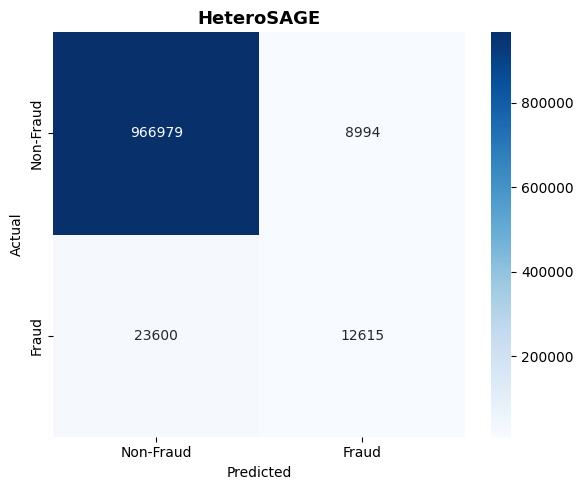

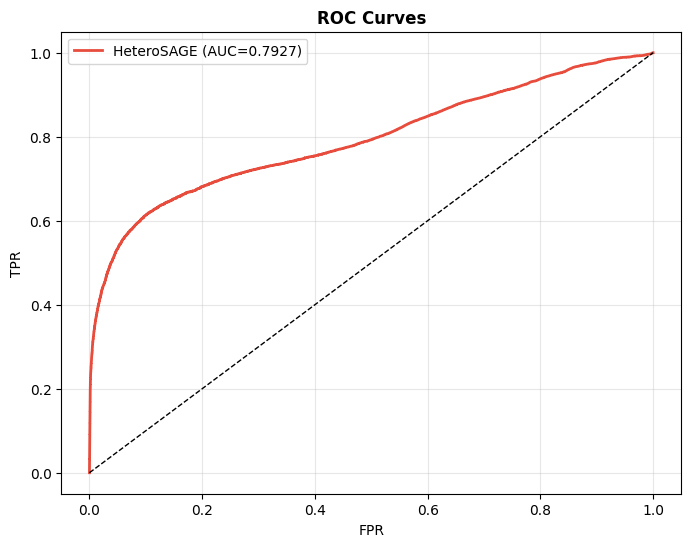

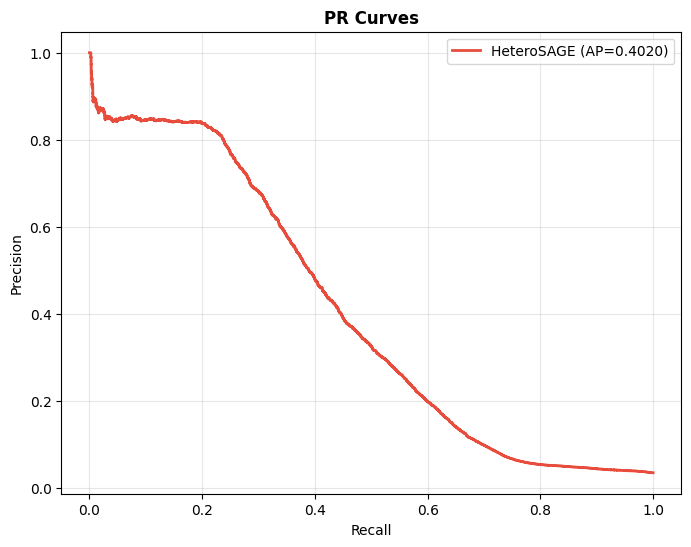

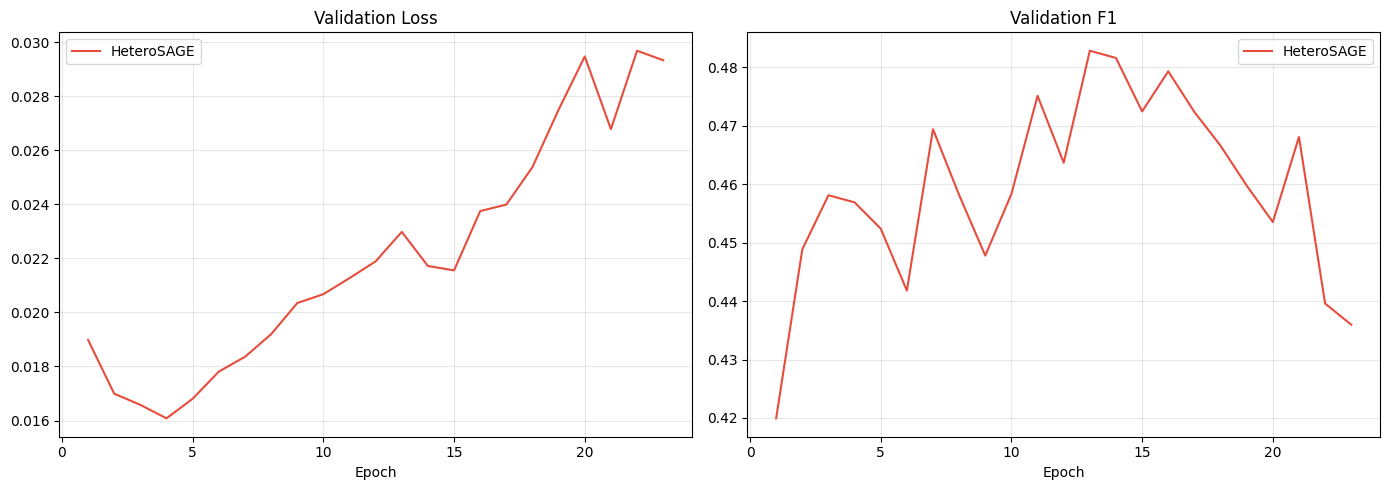

In [25]:
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Confusion Matrices
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
if len(results)==1: axes=[axes]
for ax, (nm,r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'], ax=ax)
    ax.set_title(nm, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'metrics'/'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(8,6))
for (nm,r),c in zip(results.items(), colors):
    if len(set(r['y_true']))>1:
        fpr,tpr,_ = roc_curve(r['y_true'], r['y_prob'])
        ax.plot(fpr, tpr, color=c, lw=2, label=f"{nm} (AUC={r['auc_roc']:.4f})")
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(str(OUTPUT_DIR/'metrics'/'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# PR Curves
fig, ax = plt.subplots(figsize=(8,6))
for (nm,r),c in zip(results.items(), colors):
    if len(set(r['y_true']))>1:
        prec,rec,_ = precision_recall_curve(r['y_true'], r['y_prob'])
        ax.plot(rec, prec, color=c, lw=2, label=f"{nm} (AP={r['auc_pr']:.4f})")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('PR Curves', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(str(OUTPUT_DIR/'metrics'/'pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (nm,h),c in zip(histories.items(), colors):
    ep = range(1, len(h['train_loss'])+1)
    axes[0].plot(ep, h['val_loss'], '-', color=c, label=nm)
    axes[1].plot(ep, h['val_f1'], '-', color=c, label=nm)
axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'metrics'/'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 14. Download Results

In [ ]:
!cd /content && zip -r results_v2.zip models/ output/metrics/
from google.colab import files
files.download('/content/results_v2.zip')
print('Done! Copy models/ to your local project.')